# Shipping Delay Pattern Analysis

## Objective

The objective of this analysis is to identify patterns and trends in shipment delays across the logistics network.

By examining shipment lead times and delivery performance, we aim to detect operational inefficiencies and understand which factors contribute to delivery delays.

This analysis provides valuable insights for improving logistics planning and reducing shipment delays.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/clean_shipping_data.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,lead_time,Profit_Margin
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,909,0.649231
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,909,0.653333
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,909,0.713467
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,909,0.694444
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,912,0.653333


## Dataset Inspection

Before performing delay analysis, we examine the dataset structure to confirm data types, column availability, and overall dataset integrity.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null 

## Delay Distribution Analysis

This section explores the distribution of shipping lead times across all shipments.

Understanding the distribution helps identify whether delays are concentrated in specific ranges or evenly distributed.

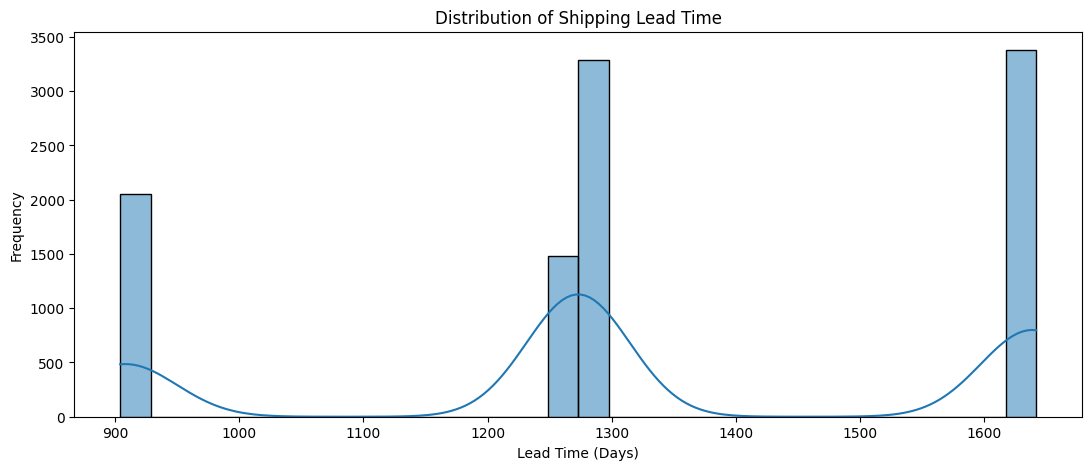

In [4]:
plt.figure(figsize=(13,5))

sns.histplot(df['lead_time'], bins=30, kde=True)

plt.title("Distribution of Shipping Lead Time")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Frequency")

plt.show()

## Shipping Delay by Ship Mode

This analysis evaluates how shipping delays vary across different shipping methods.

In [5]:
delay_by_mode = df.groupby("Ship Mode")["lead_time"].mean().reset_index()

delay_by_mode

,Ship Mode,lead_time
0,First Class,1338.275840
1,Same Day,1333.442413
2,Second Class,1323.845376
3,Standard Class,1314.334641


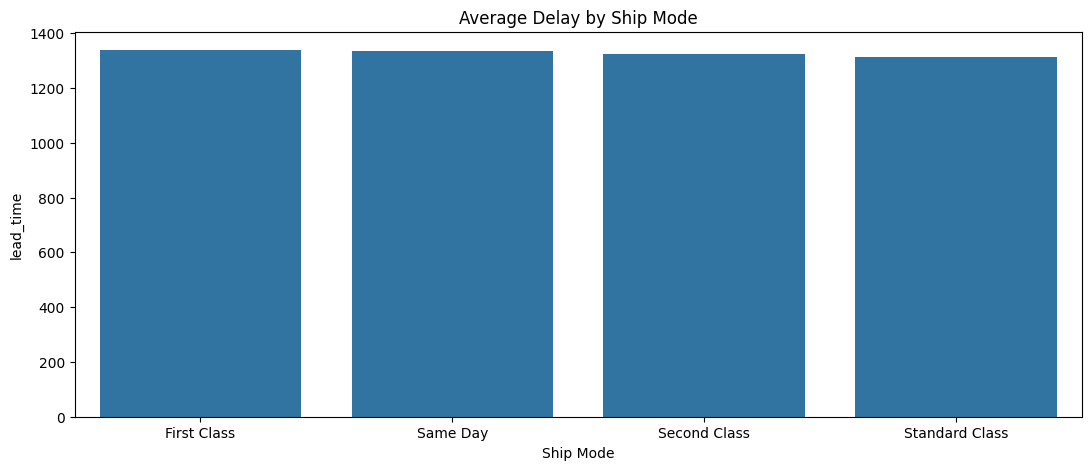

In [6]:
plt.figure(figsize=(13,5))

sns.barplot(
    data=delay_by_mode,
    x="Ship Mode",
    y="lead_time"
)

plt.title("Average Delay by Ship Mode")

plt.show()

## Geographic Delay Patterns

This section examines whether certain states or regions experience longer shipping delays.

In [7]:
delay_by_state = df.groupby("State/Province")["lead_time"].mean().sort_values(ascending=False)

delay_by_state.head(10)

State/Province
West Virginia           1638.000000
North Dakota            1637.857143
Saskatchewan            1457.000000
Manitoba                1455.333333
Iowa                    1443.900000
New Mexico              1441.837838
Vermont                 1438.909091
Prince Edward Island    1420.300000
South Dakota            1395.916667
Tennessee               1391.486339
Name: lead_time, dtype: float64

In [8]:
delay_by_state.to_csv("../data/processed/shipping_delay_patterns.csv")